In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [16]:
kpoints = bandstructkpoints2q(interpolate = 5);

In [7]:
export_hwannier("wannier", spin=Val('u'))
export_hwannier("wannier", spin=Val('d'))
export_momentum("wannier", spin=Val('u'))
export_momentum("wannier", spin=Val('d'));
export_heph("wannier", spin=Val('u'));
export_heph("wannier", spin=Val('d'));

In [5]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt")
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");
Pwannier = pwannier("wannierUp");
Heph, celleph_map = hephwannier("wannierUp"), np.loadtxt("wannierUp.mapeph.txt");
lattice_vectors = loadlattice("wannier.out");

In [6]:
force_matrix, cellph_map = phonon_force_matrix("../../BN44BC_Buckled/phonon");
phonon_bands_bn44bc = phonon_dispersion(force_matrix, cellph_map, kpointsfile="../bandstruct.kpoints", return_negative=true);

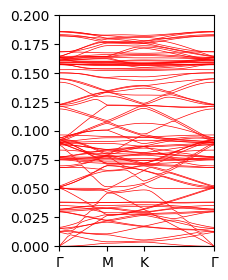

(0.0, 0.2)

In [7]:
figure(figsize=(2, 3))
plot(phonon_bands_bn44bc, color="red", linewidth=0.5)
label_plots()
ylim(0, 0.2)

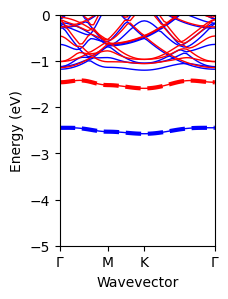

(0.0, 55.0)

In [8]:
figure(figsize=(2, 3))
plot_bands(HwannierUp, cell_mapUp, linewidth=3, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, linewidth=3, color="red", linestyle="dashed")
plot_bands("../BN44BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-5, 0)
label_plots()

In [9]:
x, y = density_of_states(HwannierUp, cell_mapUp, mesh=20, num_blocks=1000, monte_carlo=true, histogram_width=1000)

([-3.5771762785652914, -3.5761761002246635, -3.5751759218840355, -3.574175743543408, -3.57317556520278, -3.572175386862152, -3.5711752085215243, -3.5701750301808963, -3.569174851840269, -3.568174673499641  …  -1.4577983747748982, -1.4567981964342702, -1.4557980180936423, -1.4547978397530144, -1.4537976614123869, -1.452797483071759, -1.451797304731131, -1.450797126390503, -1.4497969480498756, -1.4487967697092476], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

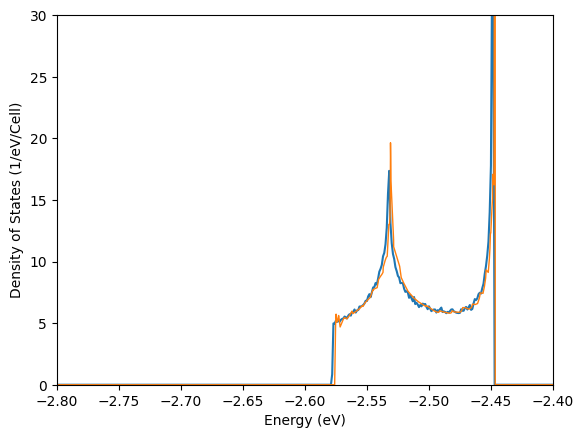

(0.0, 30.0)

In [10]:
plot(x, y)
density_of_states("../DOS/BN44BC.dosUp", linewidth=1)
xlim(-2.8, -2.4)
ylim(0, 30)

In [11]:
e, n = find_chemical_potential(x, y);

In [13]:
#Finding DOS at Fermi level
#y[argmin(abs.(n .- 0.5))]
x[argmin(abs.(n .- 0.5))]

-2.5139867024778972

In [17]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierUp, cell_mapUp, lattice_vectors, k, -2.514, Val(2), histogram_width=1000, mesh=100, num_blocks=20, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
19
[0.1058823529416, 0.0, 0.0]
20
[0.1117647058828, 0.0, 0.0]
21
[0.117647058824, 0.0, 0.0]
22
[0.123529411765, 0.0, 0.0]
23
[0.129411764706, 0.0, 0.0]
24
[0.135294117647, 0.0, 0.0]
25
[0.14117647058799998, 0.0, 0.0]
26
[0.147058823529, 0.0, 0.0]
27
[0.1529411764702, 0.0, 0.0]
28
[0.1588235294114, 0.0, 0.0]
29
[0.1647058823526, 0.0, 0.0]
30
[0.1705882352938, 0.0, 0.0]
31
[0.176470588235, 0.0, 0.0]
32
[0.1823529411762, 0.0, 0.0]
33
[0.1882352941174, 0.0, 0.0]
34


In [18]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_default = zeros(50, 200)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    for (j, ω) in enumerate(range(0.01, 0.5, length=200))
        epsilons_default[i, j] = real(ϵ(k, lattice_vectors, ω, energies, 
                smooth(real.(polarizations[i]), win_len=20), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

In [35]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_quadgk = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.01, 0.5, length=100)[1:100])
    x = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:quadgk), rtol=1e-7, atol=1e-7, δ=0.01, normalized=true))
     epsilons_quadgk[i, j] = x
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [41]:
energies = range(0, 100, length=100000)
energies = collect(energies)
epsilons_scipy = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.01, 0.5, length=100))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:scipy), limit=50, δ=0.001, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [25]:
plasmon_default = [range(0.01, 0.5, length=200)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

In [51]:
plasmon_quadgk = [range(0.01, 0.5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_quadgk[2:50, :])))];
plasmon_quadgk = [0, plasmon_quadgk...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_quadgk);
plasmon_quadgk = smooth(plasmon_quadgk, win_len=10);
plasmon_quadgk[1] = 0;

In [52]:
plasmon_scipy = [range(0.01, 0.5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_scipy[2:50, :])))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_scipy);
plasmon_scipy = smooth(plasmon_scipy, win_len=10);
plasmon_scipy[1] = 0;

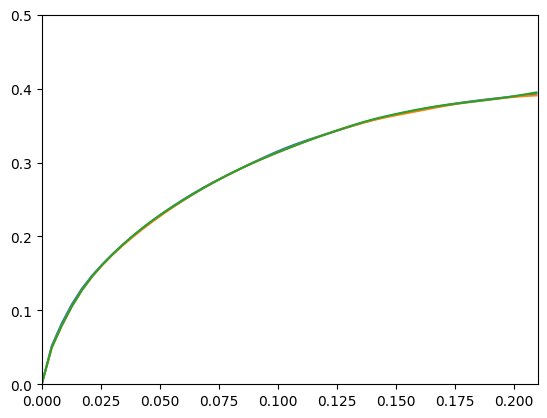

(0.0, 0.5)

In [53]:
plot(qs, plasmon_default)
plot(qs, plasmon_quadgk)
plot(qs, plasmon_scipy)

xlim(0, 0.21)
ylim(0, 0.5)

In [ ]:
np.savetxt("plasmon.txt", hcat(qs, plasmon_default, plasmon_scipy, plasmon_quadgk), header="qs, default, scipy, quadgk")

In [11]:
subsampling = returnfermikpoint(HwannierUp, cell_mapUp, -2.514, Val(2), mesh=10, num_blocks=10000, histogram_width=1000)

(Real[0.15847319054596953 0.23044158428993988 … 0.5839848222637793 0.6344027515393513; 0.2575724021671053 0.18432605553288117 … 0.21058731638483086 0.9565013073635511; 0.0 0.0 … 0.0 0.0], 0.006987999999999999)

In [12]:
tau =  τ(HwannierUp, cell_mapUp, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.01:0.01:1), -2.514, Val(:histogram), Val(2); 
mesh=20, supplysampling=subsampling, supplydos=7, num_blocks=10, fracroom=1, histogram_width=1000)

DOS at Fermi Energy is: 7
Sampling from 6988kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


100-element Vector{Float64}:
 10.193960778685401
  8.25049558659493
  6.706272465010273
  5.476944521142851
  4.495846977351301
  3.7104941234862934
  3.0796778538055114
  2.5711003364495157
  2.1594659577500335
  1.8249587208081706
  1.5520371782849467
  1.3284871927523254
  1.144681646488919
  ⋮
  0.11810674418462094
  0.11764906302311957
  0.11720344308460474
  0.11676941379732264
  0.11634652875456095
  0.11593436418313444
  0.1155325175269004
  0.11514060613532931
  0.11475826604816267
  0.1143851508680383
  0.11402093071374877
  0.11366529124747576

In [16]:
omegas = 0.01:0.01:1;
np.savetxt("tau.txt", hcat(omegas, tau))

In [24]:
tau =  JJDFTX.τ_allen(HwannierUp, cell_mapUp, Pwannier, force_matrix, cellph_map, Heph, celleph_map, collect(0.01:0.01:1), -2.514, Val(2); 
mesh=3, supplydos=7.1, num_blocks=300, fracroom=1, histogram_width=1000)

DOS at Fermi Energy is: 7.1
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
B

100-element Vector{Float64}:
  8.996114727365851
 11.283818794510251
 12.775348997623
 12.292235497660883
 11.790180963442937
 10.351076338672938
  8.871348258281213
  8.22505928729415
  6.957062679012323
  6.44033951552565
  5.703480081351346
  5.296395319225702
  4.7193361077969325
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

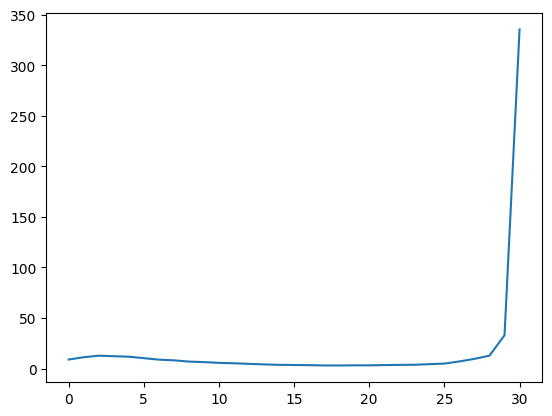

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7fa30a4c3850>

In [27]:
plot(tau)

In [28]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau))

In [31]:
omegas, tau_allen = [col for col in eachcol(np.loadtxt("tau_allen.txt"))]
omegas, taus = [col for col in eachcol(np.loadtxt("tau.txt"))]

2-element Vector{SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}}:
 [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1  …  0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
 [10.193960778685401, 8.25049558659493, 6.706272465010273, 5.476944521142851, 4.495846977351301, 3.7104941234862934, 3.0796778538055114, 2.5711003364495157, 2.1594659577500335, 1.8249587208081706  …  0.11720344308460474, 0.11676941379732264, 0.11634652875456095, 0.11593436418313444, 0.1155325175269004, 0.11514060613532931, 0.11475826604816267, 0.1143851508680383, 0.11402093071374877, 0.11366529124747576]

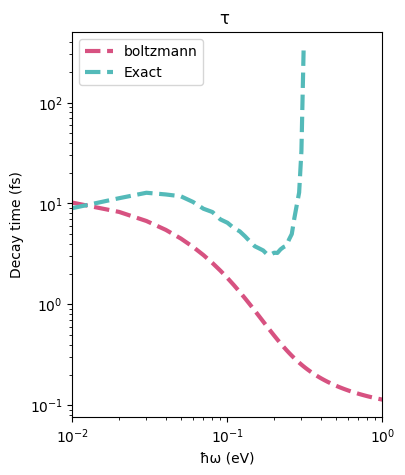

(0.01, 1)

In [32]:
color_allen = "#54BAB9"
color_taus = "#D75281"

figure(figsize=(4, 5))
title("τ ")
ylabel("Decay time (fs)")
xlabel("ħω (eV)")

loglog(omegas, taus, color=color_taus, linewidth=3, label="boltzmann", linestyle="dashed")
loglog(omegas, tau_allen, color=color_allen, linewidth=3, label="Exact", linestyle="dashed")
legend()
xlim(0.01, 1)